# Fine-tune VietOCR trên CCCD Data (v2)

**Cải tiến so với v1:**
- Image height 48px (từ 32px) — nhận dấu tiếng Việt tốt hơn
- Image max width 1024px — xử lý địa chỉ dài tốt hơn
- Data balanced: address/origin được upsample
- Confidence threshold cao hơn cho pseudo-labels
- 30K iterations (từ 15K)
- Per-field evaluation
- **Auto-save checkpoint lên Google Drive** — không mất khi runtime reset

**Chuẩn bị:**
1. Chạy ở local: `python scripts/finetune/prepare_finetune_data.py`
2. Chạy ở local: `python scripts/finetune/pack_colab_data.py --input-dir data/processed/ocr/finetune --output-prefix finetune_data`
3. Upload `finetune_data.zip` lên Google Drive root

## 1. Setup

In [1]:
!pip install -q vietocr lmdb imgaug
!pip install -q 'Pillow>=10.0,<11.0' --force-reinstall
!pip install -q torchvision --upgrade

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.0/948.0 kB 29.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.9/133.9 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 115.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 333.1/333.1 kB 30.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 64.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
vietocr 0.3.13 requires pillow==10.2.0, but you have pillow 10.4.0 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 84.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 532.3/532.3 MB 2.5 MB/s eta 0:00:00
   ━

In [3]:
import numpy as np
if not hasattr(np, 'sctypes'):
    np.sctypes = {
        'int': [np.int8, np.int16, np.int32, np.int64],
        'uint': [np.uint8, np.uint16, np.uint32, np.uint64],
        'float': [np.float16, np.float32, np.float64],
        'complex': [np.complex64, np.complex128],
        'others': [bool, object, bytes, str, np.void],
    }

import torch
print(f'PyTorch: {torch.__version__}')
print(f'CUDA: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    vram_gb = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f'VRAM: {vram_gb:.1f} GB')
    BATCH_SIZE = 16 if vram_gb >= 14 else 8
else:
    BATCH_SIZE = 4
print(f'Batch size: {BATCH_SIZE}')

PyTorch: 2.12.0+cu130
CUDA: True
GPU: Tesla T4
VRAM: 14.6 GB
Batch size: 16


## 2. Mount Google Drive & giải nén data

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import os, zipfile, glob, shutil

ZIP_PATH = '/content/drive/MyDrive/finetune_data.zip'
WORK_DIR = '/content/vietocr_finetune_v2'
DRIVE_CHECKPOINT = '/content/drive/MyDrive/vietocr_v2_checkpoint.ckpt'

os.makedirs(WORK_DIR, exist_ok=True)

if not os.path.exists(os.path.join(WORK_DIR, 'train_annotation.txt')):
    print('Extracting data...')
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(WORK_DIR)

    ann = glob.glob(os.path.join(WORK_DIR, '**', 'train_annotation.txt'), recursive=True)
    if ann and os.path.dirname(ann[0]) != WORK_DIR:
        sub = os.path.dirname(ann[0])
        print(f'  Moving files from {sub} to {WORK_DIR}')
        for item in os.listdir(sub):
            src = os.path.join(sub, item)
            dst = os.path.join(WORK_DIR, item)
            if os.path.exists(dst):
                if os.path.isdir(dst): shutil.rmtree(dst)
                else: os.remove(dst)
            shutil.move(src, dst)
    print('Done!')
else:
    print('Data already extracted.')

os.chdir(WORK_DIR)

import re
from collections import Counter

for split in ('train', 'val'):
    fname = f'{split}_annotation.txt'
    field_counts = Counter()
    total = 0
    ok = 0
    with open(fname, encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split('\t')
            if len(parts) < 2: continue
            total += 1
            if os.path.exists(parts[0]): ok += 1
            m = re.search(r'field_crops/(\w+)/', parts[0])
            if m: field_counts[m.group(1)] += 1
    print(f'\n{split}: {total} samples, {ok} images found')
    for field, count in field_counts.most_common():
        print(f'  {field}: {count} ({count/total*100:.1f}%)')

Extracting data...
Done!

train: 23040 samples, 23040 images found
  origin: 5592 (24.3%)
  name: 5157 (22.4%)
  id: 4673 (20.3%)
  address: 4374 (19.0%)
  birth: 3244 (14.1%)

val: 1314 samples, 1314 images found
  name: 431 (32.8%)
  id: 383 (29.1%)
  birth: 226 (17.2%)
  origin: 172 (13.1%)
  address: 102 (7.8%)


## 3. Config

In [6]:
import yaml

ITERS = 30000
MAX_LR = 0.00003
IMAGE_HEIGHT = 48
IMAGE_MAX_WIDTH = 1024

config_dict = {
    'vocab': 'aAàÀảẢãÃáÁạẠăĂằẰẳẲẵẴắẮặẶâÂầẦẩẨẫẪấẤậẬbBcCdDđĐeEèÈẻẺẽẼéÉẹẸêÊềỀểỂễỄếẾệỆfFgGhHiIìÌỉỈĩĨíÍịỊjJkKlLmMnNoOòÒỏỎõÕóÓọỌôÔồỒổỔỗỖốỐộỘơƠờỜởỞỡỠớỚợỢpPqQrRsStTuUùÙủỦũŨúÚụỤưƯừỪửỬữỮứỨựỰvVwWxXyYỳỲỷỶỹỸýÝỵỴzZ0123456789!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~ ',
    'backbone': 'vgg19_bn',
    'cnn': {'ss': [[2,2],[2,2],[2,1],[2,1],[1,1]], 'ks': [[2,2],[2,2],[2,1],[2,1],[1,1]], 'hidden': 256, 'dropout': 0.5},
    'transformer': {'d_model': 256, 'nhead': 8, 'num_encoder_layers': 6, 'num_decoder_layers': 6, 'dim_feedforward': 2048, 'max_seq_length': 1024, 'pos_dropout': 0.1, 'trans_dropout': 0.1},
    'seq_modeling': 'transformer',
    'pretrain': 'https://vocr.vn/data/vietocr/vgg_transformer.pth',
    'weights': '',
    'device': 'cuda:0',
    'quiet': True,
    'dataset': {
        'name': 'cccd_finetune_v2',
        'data_root': WORK_DIR,
        'train_annotation': 'train_annotation.txt',
        'valid_annotation': 'val_annotation.txt',
        'image_height': IMAGE_HEIGHT,
        'image_min_width': 48,
        'image_max_width': IMAGE_MAX_WIDTH,
    },
    'dataloader': {'num_workers': 2, 'pin_memory': True},
    'predictor': {'beamsearch': False},
    'trainer': {
        'batch_size': BATCH_SIZE,
        'iters': ITERS,
        'print_every': 200,
        'valid_every': 3000,
        'checkpoint': f'{WORK_DIR}/checkpoint_v2.ckpt',
        'export': f'{WORK_DIR}/vietocr_cccd_v2.pth',
        'metrics': 2000,
        'log': f'{WORK_DIR}/train_log_v2',
    },
    'optimizer': {'max_lr': MAX_LR, 'pct_start': 0.05},
    'aug': {'image_aug': True, 'masked_language_model': True},
}

with open('config_v2.yml', 'w', encoding='utf-8') as f:
    yaml.dump(config_dict, f, allow_unicode=True)

print('Config v2 saved.')
print(f'  image_height:  {IMAGE_HEIGHT}')
print(f'  max_width:     {IMAGE_MAX_WIDTH}')
print(f'  batch_size:    {BATCH_SIZE}')
print(f'  iters:         {ITERS}')
print(f'  max_lr:        {MAX_LR}')

Config v2 saved.
  image_height:  48
  max_width:     1024
  batch_size:    16
  iters:         30000
  max_lr:        3e-05


## 4. Train

In [7]:
from vietocr.tool.config import Cfg
from vietocr.model.trainer import Trainer

config = Cfg.load_config_from_file('config_v2.yml')
trainer = Trainer(config, pretrained=True)

# --- Auto-resume từ Google Drive nếu có checkpoint ---
LOCAL_CKPT = config['trainer']['checkpoint']

if os.path.exists(DRIVE_CHECKPOINT):
    print(f'Found checkpoint trên Drive, copying to local...')
    shutil.copy2(DRIVE_CHECKPOINT, LOCAL_CKPT)

if os.path.exists(LOCAL_CKPT):
    print(f'Resuming từ checkpoint: {LOCAL_CKPT}')
    trainer.load_checkpoint(LOCAL_CKPT)
else:
    print('Không có checkpoint, train từ đầu.')

print('Model loaded.')

Downloading: "https://download.pytorch.org/models/vgg19_bn-c79401a0.pth" to /root/.cache/torch/hub/checkpoints/vgg19_bn-c79401a0.pth


100%|██████████| 548M/548M [00:05<00:00, 96.5MB/s]
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:143: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.encoder = TransformerEncoder(
18533it [00:11, 1601.96it/s]
Create train_cccd_finetune_v2: 100%|████████████████████████| 23040/23040 [00:07<00:00, 2889.13it/s]

Created dataset with 23039 samples



Create valid_cccd_finetune_v2: 100%|██████████████████████████| 1314/1314 [00:00<00:00, 4083.51it/s]

Created dataset with 1313 samples



valid_cccd_finetune_v2 build cluster: 100%|█████████████████| 1313/1313 [00:00<00:00, 136463.50it/s]

Không có checkpoint, train từ đầu.
Model loaded.


In [8]:
import threading, time

def auto_save_checkpoint(interval_sec=600):
    """Tự động copy checkpoint lên Google Drive mỗi 10 phút."""
    while True:
        time.sleep(interval_sec)
        local_ckpt = config['trainer']['checkpoint']
        if os.path.exists(local_ckpt):
            try:
                shutil.copy2(local_ckpt, DRIVE_CHECKPOINT)
                print(f'\n[Auto-save] Checkpoint saved to Drive at {time.strftime("%H:%M:%S")}')
            except Exception as e:
                print(f'\n[Auto-save] Failed: {e}')

saver = threading.Thread(target=auto_save_checkpoint, daemon=True)
saver.start()
print('Auto-save checkpoint lên Drive mỗi 10 phút.')

trainer.train()

trainer.save_weights(config['trainer']['export'])
trainer.save_checkpoint(config['trainer']['checkpoint'])

# Save checkpoint lên Drive ngay sau khi train xong
shutil.copy2(config['trainer']['checkpoint'], DRIVE_CHECKPOINT)
print(f"\nModel saved to: {config['trainer']['export']}")
print(f'Checkpoint saved to Drive: {DRIVE_CHECKPOINT}')

Auto-save checkpoint lên Drive mỗi 10 phút.
iter: 000200 - train loss: 1.109 - lr: 2.45e-06 - load time: 0.31 - gpu time: 47.65
iter: 000400 - train loss: 0.981 - lr: 5.97e-06 - load time: 0.16 - gpu time: 48.72
iter: 000600 - train loss: 0.885 - lr: 1.12e-05 - load time: 0.12 - gpu time: 51.57
iter: 000800 - train loss: 0.805 - lr: 1.71e-05 - load time: 0.14 - gpu time: 50.77
iter: 001000 - train loss: 0.754 - lr: 2.28e-05 - load time: 0.13 - gpu time: 52.05
iter: 001200 - train loss: 0.728 - lr: 2.73e-05 - load time: 0.13 - gpu time: 51.23
iter: 001400 - train loss: 0.699 - lr: 2.97e-05 - load time: 0.15 - gpu time: 50.51
iter: 001600 - train loss: 0.677 - lr: 3.00e-05 - load time: 0.34 - gpu time: 51.52
iter: 001800 - train loss: 0.673 - lr: 3.00e-05 - load time: 0.15 - gpu time: 52.65
iter: 002000 - train loss: 0.660 - lr: 3.00e-05 - load time: 0.12 - gpu time: 50.75
iter: 002200 - train loss: 0.676 - lr: 3.00e-05 - load time: 0.14 - gpu time: 50.17
iter: 002400 - train loss: 0.653

## 5. Evaluate

In [9]:
trainer.beamsearch = False
acc_full, acc_char = trainer.precision(sample=2000)
print(f'Full sequence accuracy: {acc_full:.4f}')
print(f'Per character accuracy: {acc_char:.4f}')

Full sequence accuracy: 0.7229
Per character accuracy: 0.8897


In [10]:
# Per-field evaluation
import re
import random
from collections import defaultdict
from PIL import Image
from vietocr.tool.translate import translate

random.seed(42)
field_results = defaultdict(lambda: {'total': 0, 'correct': 0, 'cer_sum': 0.0})

with open('val_annotation.txt', encoding='utf-8') as f:
    val_lines = [line.strip() for line in f if line.strip()]

sample = random.sample(val_lines, min(500, len(val_lines)))

for line in sample:
    parts = line.split('\t', 1)
    if len(parts) != 2: continue
    img_path, gt = parts
    m = re.search(r'field_crops/(\w+)/', img_path)
    field = m.group(1) if m else 'unknown'
    try:
        img = Image.open(img_path).convert('RGB')
        pred, _ = translate(img, trainer.model, trainer.config)
        pred = pred.strip()
    except: continue

    field_results[field]['total'] += 1
    if pred == gt:
        field_results[field]['correct'] += 1
    if gt:
        max_len = max(len(gt), len(pred))
        errs = sum(1 for i in range(max_len) if i >= len(gt) or i >= len(pred) or gt[i] != pred[i])
        errs += abs(len(gt) - len(pred))
        field_results[field]['cer_sum'] += errs / len(gt)

print(f"{'Field':<12s} {'Accuracy':>10s} {'CER':>8s} {'N':>6s}")
print('-' * 40)
for field in ['id', 'birth', 'name', 'origin', 'address']:
    r = field_results.get(field)
    if not r or r['total'] == 0: continue
    acc = r['correct'] / r['total']
    cer = r['cer_sum'] / r['total']
    print(f"{field:<12s} {acc:>9.1%} {cer:>7.3f} {r['total']:>6d}")
total_n = sum(r['total'] for r in field_results.values())
total_c = sum(r['correct'] for r in field_results.values())
print(f"{'OVERALL':<12s} {total_c/max(1,total_n):>9.1%} {'':>8s} {total_n:>6d}")

Field          Accuracy      CER      N
----------------------------------------
OVERALL           0.0%               0


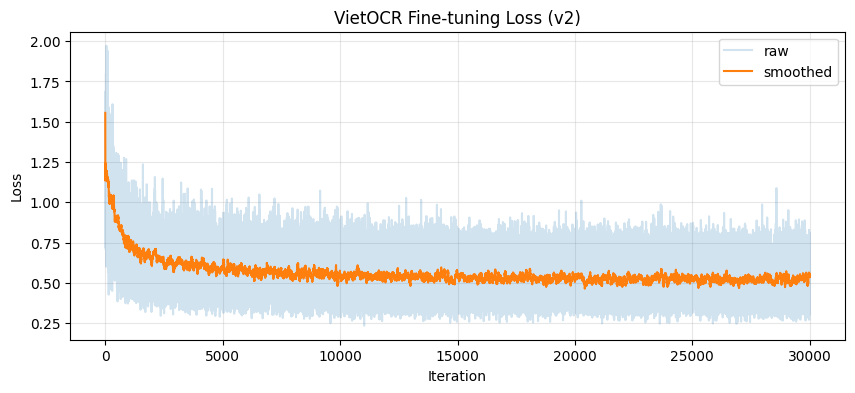

In [11]:
# Loss curve
import matplotlib.pyplot as plt

iters = [x[0] for x in trainer.train_losses]
losses = [x[1] for x in trainer.train_losses]
window = 50
smooth = [sum(losses[max(0,i-window):i+1])/len(losses[max(0,i-window):i+1]) for i in range(len(losses))]

plt.figure(figsize=(10, 4))
plt.plot(iters, losses, alpha=0.2, label='raw')
plt.plot(iters, smooth, label='smoothed')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('VietOCR Fine-tuning Loss (v2)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 6. Copy weights về Google Drive

In [12]:
import shutil

drive_out = '/content/drive/MyDrive/vietocr_cccd_v2.pth'
shutil.copy2(config['trainer']['export'], drive_out)
print(f'Weights copied to: {drive_out}')
print()
print('Download file vietocr_cccd_v2.pth từ Google Drive,')
print('đặt vào thư mục weights/ trong project:')
print('  weights/vietocr_cccd_v2.pth')
print()
print('Pipeline sẽ tự động load fine-tuned model v2.')

Weights copied to: /content/drive/MyDrive/vietocr_cccd_v2.pth

Download file vietocr_cccd_v2.pth từ Google Drive,
đặt vào thư mục weights/ trong project:
  weights/vietocr_cccd_v2.pth

Pipeline sẽ tự động load fine-tuned model v2.
